## ASSIGNMENT 8-VB

In [1]:
# Basic import statements
import pandas as pd
import numpy as np

# For Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For Model building
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve


## 1. loading training and test datasets, added a new column "data_file" to both datasets and then merged the datasets into titanic_df

In [2]:
# loading datasets of training and test
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

# Adding a new column "data_file" to the datasets
train_df['data_file'] = 'Train'
test_df['data_file'] = 'Test'

# Merging both datasets
titanic_df = pd.concat([train_df, test_df], ignore_index=True)

# Displaying merged dataset
titanic_df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,data_file
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Train
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Train
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Train
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Train
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Train


In [3]:
# Displaying column names, data types, non-null counts
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
 12  data_file    1309 non-null   object 
dtypes: float64(3), int64(4), object(6)
memory usage: 133.1+ KB


In [4]:
#displaying last 5 rows
titanic_df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,data_file
1304,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S,Test
1305,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,Test
1306,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,Test
1307,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S,Test
1308,1309,NaN,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,NaN,C,Test


## EDA

<Axes: >

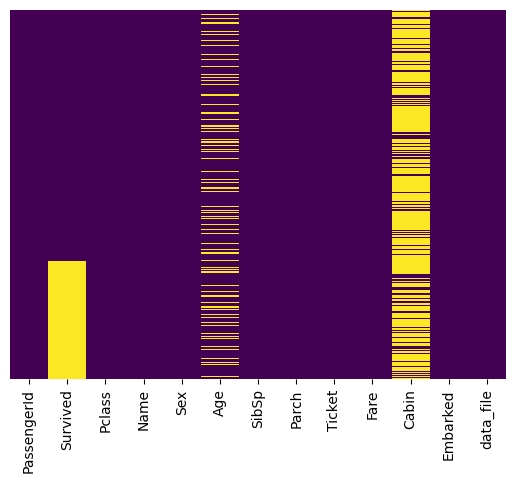

In [5]:
# Visualizing missing values in the dataset using a heatmap
sns.heatmap(titanic_df.isnull(),yticklabels=False,cbar=False,cmap='viridis')

<Axes: xlabel='Survived', ylabel='count'>

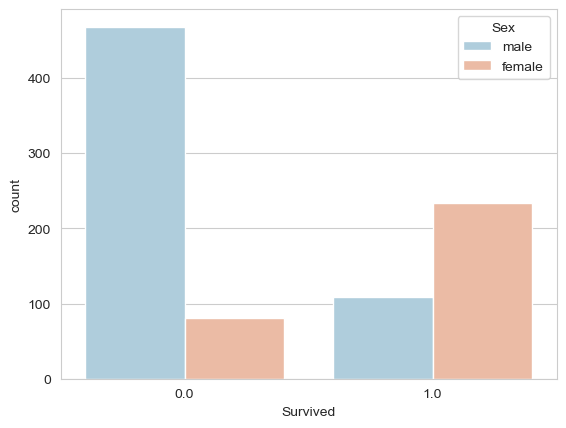

In [6]:
# Setting background style of the plot to white grid  
sns.set_style('whitegrid')

# Plotting survival counts split by gender
sns.countplot(x='Survived', data=titanic_df, hue='Sex',palette='RdBu_r')

<Axes: xlabel='Survived', ylabel='count'>

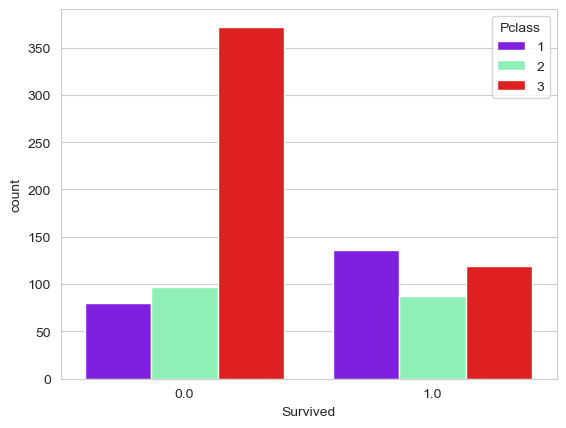

In [7]:
# Showing survival counts by passenger class
sns.countplot(x='Survived', data=titanic_df, hue='Pclass',palette='rainbow')

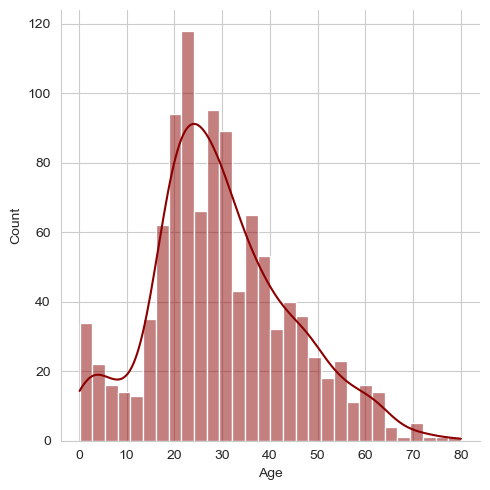

In [8]:
# Plotting age distribution with KDE curve
sns.displot(titanic_df['Age'].dropna(),kde=True,color='darkred',bins=30)

<Axes: >

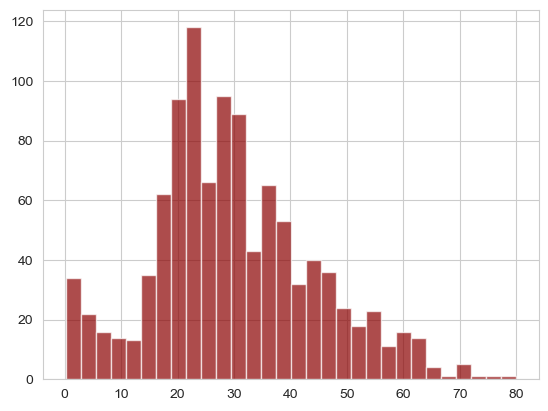

In [9]:
# Plotting histogram of passenger ages
titanic_df['Age'].hist(bins=30,color='darkred',alpha=0.7)

<Axes: xlabel='SibSp', ylabel='count'>

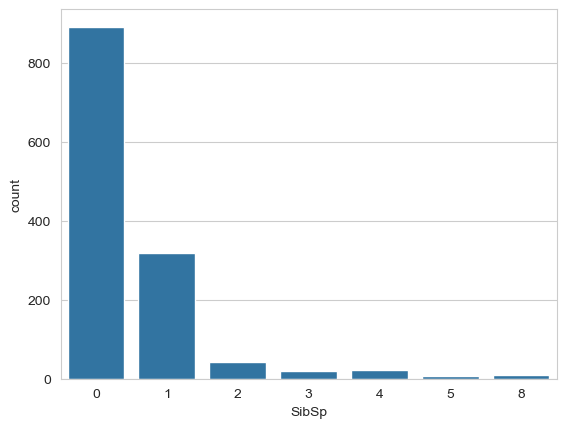

In [10]:
# Counting of passengers by number of siblings/spouses aboard
sns.countplot(x='SibSp',data=titanic_df)

<Axes: >

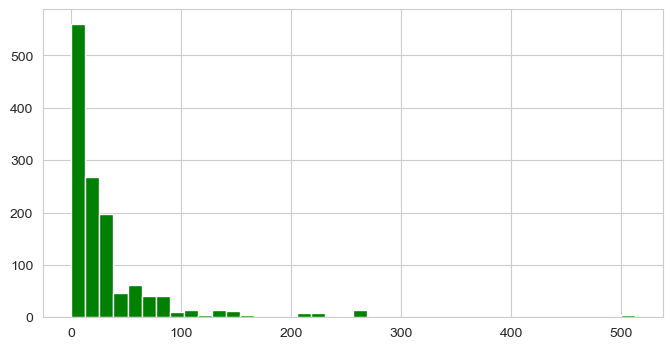

In [11]:
# Histogram of passenger fares
titanic_df['Fare'].hist(color='green',bins=40,figsize=(8,4))

### Data Preprocessing

<Axes: xlabel='Pclass', ylabel='Age'>

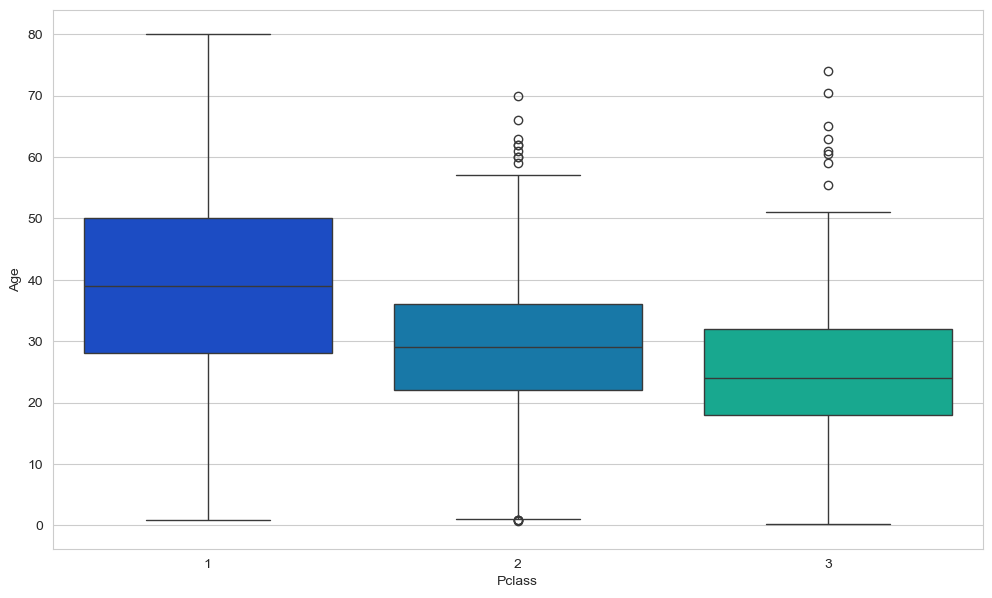

In [12]:
plt.figure(figsize=(12, 7))
# Boxplot of Age distribution across passenger classes
sns.boxplot(x='Pclass',y='Age',data=titanic_df,palette='winter')

In [13]:
# Confirming the average values to be used in an imputation function
titanic_df.groupby(by='Pclass', axis=0)['Age'].mean()

Pclass
1    39.159930
2    29.506705
3    24.816367
Name: Age, dtype: float64

In [14]:
def impute_age(cols):
    Age = cols[0]
    Pclass = cols[1]
    # If Age is missing, impute based on passenger class
    if pd.isnull(Age):

        if Pclass == 1:
            return 39

        elif Pclass == 2:
            return 30

        else:
            return 25
# Return original Age if not missing
    else:
        return Age

In [15]:
# Filling missing Age values based on Pclass avg age value which we got from mean 
titanic_df['Age'] = titanic_df[['Age','Pclass']].apply(impute_age,axis=1)

<Axes: >

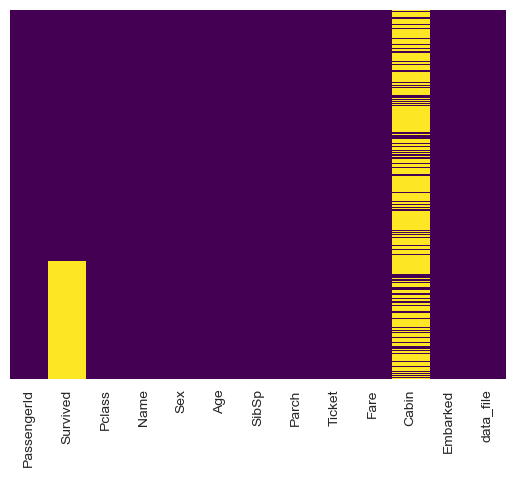

In [16]:
# Visualizing missing values in the dataset
sns.heatmap(titanic_df.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [17]:
# Removing 'Cabin' column due to many missing values
titanic_df.drop('Cabin',axis=1,inplace=True)

In [18]:
# Displaying the first 5 rows of the dataset
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,data_file
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Train
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,Train
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Train
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,Train
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Train


### Converting categorical features

In [20]:
# Show summary of the dataset including column types and non-null counts
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1309 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Embarked     1307 non-null   object 
 11  data_file    1309 non-null   object 
dtypes: float64(3), int64(4), object(5)
memory usage: 122.8+ KB


In [21]:
# Converting 'Sex' feature, drop first category to avoid dummy variable
sex = pd.get_dummies(titanic_df['Sex'],drop_first=True)
# Converting 'Embarked', drop first category to avoid dummy variable
embark = pd.get_dummies(titanic_df['Embarked'],drop_first=True)

In [22]:
# Display the first 5 rows of the encoded 'Sex' column
sex.head()

,male
0,True
1,False
2,False
3,False
4,True


In [23]:
# Remove original categorical and unnecessary columns
titanic_df.drop(['Sex','Embarked','Name','Ticket'],axis=1,inplace=True)

In [24]:
# Add encoded 'Sex' and 'Embarked' columns back to the dataset
titanic_df = pd.concat([titanic_df, sex, embark], axis=1)

In [25]:
#display first five rows
titanic_df.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,data_file,male,Q,S
0,1,0.0,3,22.0,1,0,7.2500,Train,True,False,True
1,2,1.0,1,38.0,1,0,71.2833,Train,False,False,False
2,3,1.0,3,26.0,0,0,7.9250,Train,False,False,True
3,4,1.0,1,35.0,1,0,53.1000,Train,False,False,True
4,5,0.0,3,35.0,0,0,8.0500,Train,True,False,True


In [26]:
from sklearn.model_selection import train_test_split

In [27]:
# Splitting back into train and test based on "data_file" column
train_data = titanic_df[titanic_df['data_file'] == 'Train'].copy()
test_data = titanic_df[titanic_df['data_file'] == 'Test'].copy()

# Drop the helper column 'data_file'
train_data.drop('data_file', axis=1, inplace=True)
test_data.drop('data_file', axis=1, inplace=True)

# Separate features and target
X_train = train_data.drop('Survived', axis=1)
y_train = train_data['Survived']

# Test set doesn't have target variable
X_test = test_data.drop('Survived', axis=1, errors='ignore')

# display shapes to check dataset before training the model
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (891, 9)
y_train shape: (891,)
X_test shape: (418, 9)


In [29]:
#display first five rows
X_test.head()

,PassengerId,Pclass,Age,SibSp,Parch,Fare,male,Q,S
891,892,3,34.5,0,0,7.8292,True,True,False
892,893,3,47.0,1,0,7.0000,False,False,True
893,894,2,62.0,0,0,9.6875,True,True,False
894,895,3,27.0,0,0,8.6625,True,False,True
895,896,3,22.0,1,1,12.2875,False,False,True


In [34]:
# Remove any rows with missing values in the test set
X_test.dropna(inplace=True)
# Display summary of the cleaned test dataset
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 417 entries, 891 to 1308
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  417 non-null    int64  
 1   Pclass       417 non-null    int64  
 2   Age          417 non-null    float64
 3   SibSp        417 non-null    int64  
 4   Parch        417 non-null    int64  
 5   Fare         417 non-null    float64
 6   male         417 non-null    bool   
 7   Q            417 non-null    bool   
 8   S            417 non-null    bool   
dtypes: bool(3), float64(2), int64(4)
memory usage: 24.0 KB


In [30]:
from sklearn.linear_model import LogisticRegression

In [70]:
from sklearn.model_selection import train_test_split
# Splitting training data into training and validation sets - 70% train, 30% validation
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.3, random_state=45)


In [67]:
# Display the dimensions (rows, columns) of the validation set
X_val.shape

(268, 9)

## Fitting, Predicting and Model evaluation

In [68]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Fitting model
model = LogisticRegression(max_iter=1000)
model.fit(X_tr, y_tr)

# Predict on validation set
y_pred = model.predict(X_val)

# Model Evaluation
print("Accuracy:", accuracy_score(y_val, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))
print("Classification Report:\n", classification_report(y_val, y_pred))


Accuracy: 0.8283582089552238
Confusion Matrix:
 [[152  26]
 [ 20  70]]
Classification Report:
               precision    recall  f1-score   support

         0.0       0.88      0.85      0.87       178
         1.0       0.73      0.78      0.75        90

    accuracy                           0.83       268
   macro avg       0.81      0.82      0.81       268
weighted avg       0.83      0.83      0.83       268

